In [ ]:
#Week 6 -3 Linear regression
#Bolortulga Seded(24045487)
#17 March 2026

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
%matplotlib inline
df = pd.read_csv('diabetes (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


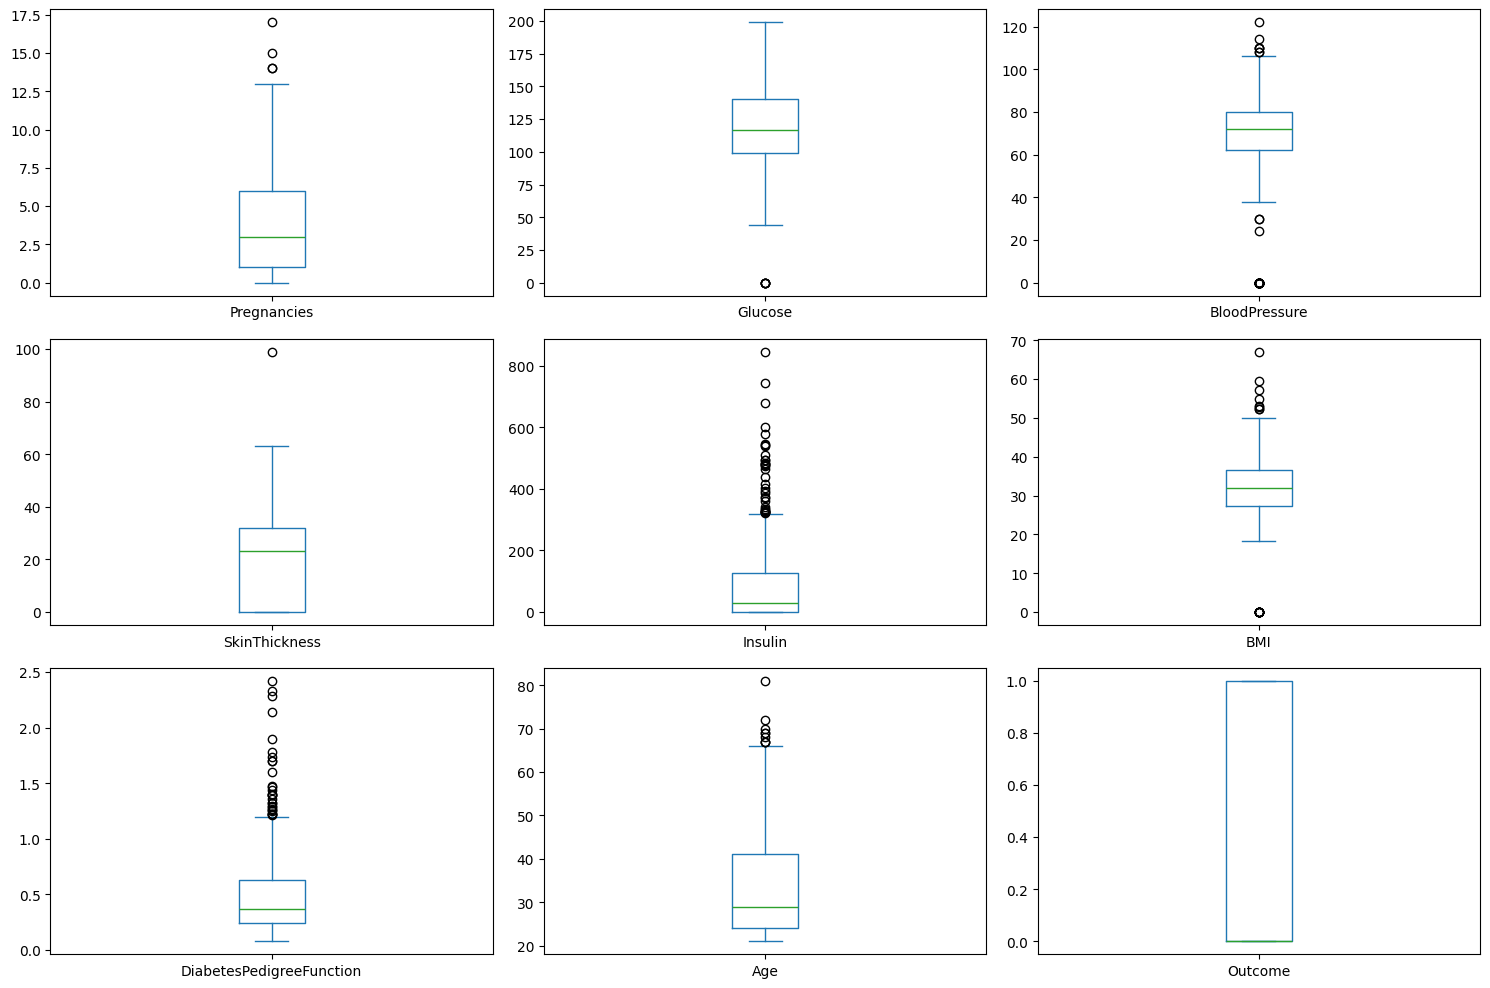

In [4]:
df.plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(15,10))
plt.tight_layout()
plt.show()

In [6]:
df.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


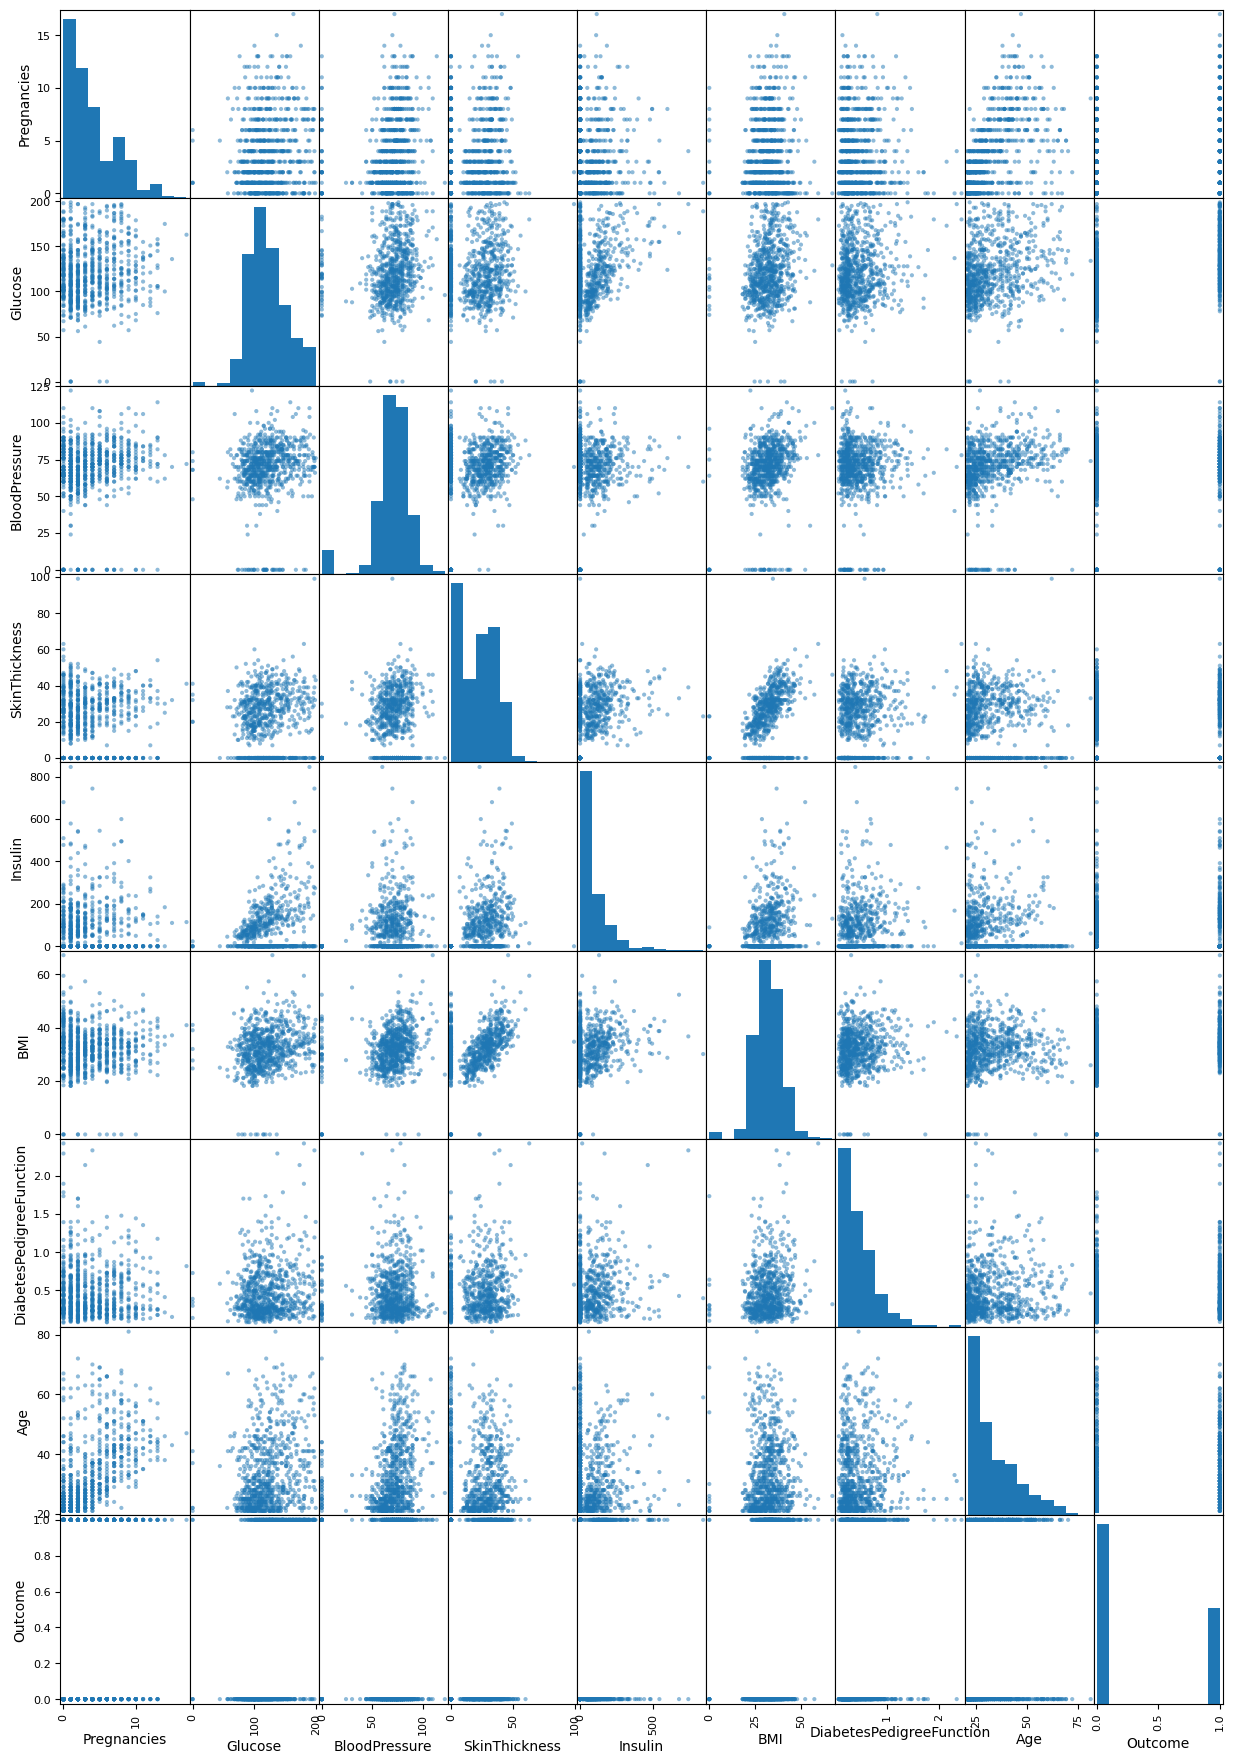

In [8]:
pd.plotting.scatter_matrix(df, figsize=(15,22))
plt.show()

In [10]:
input_cols = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction','Age']
output_variable = ['Glucose']

X = df[input_cols]
Y = df[output_variable]

linreg = LinearRegression()
linreg.fit(X,Y)
print('Intercept:', linreg.intercept_)
print('Coefficients:', list(zip(input_cols,linreg.coef_[0])))

Intercept: [66.24115607]
Coefficients: [('Pregnancies', np.float64(0.05891176930996252)), ('BloodPressure', np.float64(0.07003275512302648)), ('SkinThickness', np.float64(-0.3342491014334847)), ('Insulin', np.float64(0.10047853204004831)), ('BMI', np.float64(0.7502945169078947)), ('DiabetesPedigreeFunction', np.float64(6.316243242735713)), ('Age', np.float64(0.6452603920384834))]


In [11]:

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=12)

print(X_train.shape)
print(X_test.shape)

(537, 7)
(231, 7)


In [12]:

lin_reg = LinearRegression()
model = lin_reg.fit(X_train, y_train)

print('R-Squared (training):', model.score(X_train, y_train))

R-Squared (training): 0.2448578751266628


In [13]:
predicted = model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, predicted))
print('MSE:', metrics.mean_squared_error(y_test, predicted))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predicted)))
print('R-Squared (test):', metrics.r2_score(y_test, predicted))

MAE: 23.126955822595214
MSE: 927.6857822300509
RMSE: 30.45793463500194
R-Squared (test): 0.19058582703785742


In [14]:
y_null = np.zeros_like(y_test, dtype=float)
y_null.fill(y_test.values.mean())

print('Null RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_null)))
print('Model RMSE should be lower than Null RMSE for the model to be useful.')

Null RMSE: 33.85439429000893
Model RMSE should be lower than Null RMSE for the model to be useful.


In [15]:
def train_test_rmse(feature_cols):
    X = df[feature_cols]
    y = df['Glucose']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    y_pred = linreg.predict(X_test)
    return np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print('All features:', train_test_rmse(input_cols))
print('BMI + Age + Insulin:', train_test_rmse(['BMI', 'Age', 'Insulin']))
print('BMI + Insulin:', train_test_rmse(['BMI', 'Insulin']))
print('Age + Insulin:', train_test_rmse(['Age', 'Insulin']))

All features: 30.45793463500194
BMI + Age + Insulin: 30.847641868467896
BMI + Insulin: 31.599815019927455
Age + Insulin: 31.16397512921351
